## My predictions

**1. Which language will need the most tokens?**

I expect **Chinese to be the one with most tokens**. I expect **English to need the fewest tokens** and **Turkish in between**.

**2. What will the larger BPE vocabulary change?**

Fewer tokens for every language and more characters per token. I expect the **biggest improvement for Chinese** since 10,000 slots are enough to give most common characters their own token. English should improve too and Turkish should sit between them: frequent stems and suffixes become tokens, but the huge number of different inflected forms is still split.

**3. What kinds of units will BPE learn?**

- **English:** frequent whole words (`the`, `of`, `and`, ` in`), common suffixes/prefixes (`ing`, `tion`, `ed`, `re`). Note that a leading space will be attached to word tokens because of how byte-level BPE handles whitespace.
- **Turkish:** I dont know much about the language so im planning to experiment it as i go.
- **Chinese:** Same as Turkish.

**4. Which tokenizer will work best for language modeling?**

My guess is the **BPE-2k or BPE-10k** and I lean to **BPE-2k** on this small dataset : shorter sequences than character-level (so the Transformer sees more context per position and training is cheaper) but with a small embedding table and few rare tokens that appear too seldom to be learned well. The character-level model should have the longest sequences and must learn spelling from scratch, so I expect it to be worst or at least the slowest. I'm least sure about BPE-10k: it has the shortest sequences, but many of its tokens will be rare in such a small corpus.
    

### Part 1

In [129]:
import os, random
import pandas as pd
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, normalizers

DATA_DIR = "/srv/data/lt2326-h26/a1"

OUT_DIR = "outputs_part1"
os.makedirs(OUT_DIR, exist_ok=True)

LANGS = ["en", "tr", "zh"]           # the three languages
SEED = 2326                          # same seed as the dataset metadata
random.seed(SEED)

## 1.1 Load the data
Each file has one sentence per line. We read **train** to build tokenizers and **valid** to analyse them

In [130]:
def read_lines(path):
    # Reading a text file, one sentence per line, skipping empty lines
    with open(path, encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f if line.strip()]

train = {lang: read_lines(f"{DATA_DIR}/train/{lang}.txt") for lang in LANGS}
valid = {lang: read_lines(f"{DATA_DIR}/valid/{lang}.txt") for lang in LANGS}

# check: sentence and character counts if it matches metadata.json
for lang in LANGS:
    print(lang,
          "| train sentences:", len(train[lang]), "chars:", sum(len(s) for s in train[lang]),
          "| valid sentences:", len(valid[lang]), "chars:", sum(len(s) for s in valid[lang]))

en | train sentences: 36004 chars: 2946215 | valid sentences: 4540 chars: 368269
tr | train sentences: 30379 chars: 2946140 | valid sentences: 3735 chars: 368383
zh | train sentences: 75962 chars: 2946177 | valid sentences: 9554 chars: 368266


## 1.2 Tokenizer 1: character level

The vocabulary is every distinct character seen in the **training** data only.
A character that first shows up in validation/test (for example: a rare Chinese character) is mapped to a special `<unk>` token instead of crashing.
I also count how often that happens, so we know how much information this loses.

In [131]:
class CharTokenizer:
    def __init__(self, sentences):
        # sorted set of all characters in the training text 
        #id 0 is reserved for <unk>
        chars = sorted(set("".join(sentences)))
        self.itos = ["<unk>"] + chars                        # id ---> token
        self.stoi = {c: i for i, c in enumerate(self.itos)}  # token ----> id

    def encode(self, text):
        # unseen characters get id 0 (<unk>)
        return [self.stoi.get(c, 0) for c in text]

    def encode_batch(self, sentences):
        return [self.encode(s) for s in sentences]

    def to_tokens(self, text):
        # human-readable tokens (for the examples section)
        return [c if c in self.stoi else "<unk>" for c in text]

    def vocab_size(self):
        return len(self.itos)

    def unk_id(self):
        return 0

# Building it from aLL training sentences of all three languages (one shared vocabulary)
all_train = [s for lang in LANGS for s in train[lang]]
char_tok = CharTokenizer(all_train)
print("Character vocabulary size:", char_tok.vocab_size())

Character vocabulary size: 9443


## 1.3 Tokenizers 2 and 3: BPE with a small and a large vocabulary

**Choices and why**
- **Library:** Hugging Face `tokenizers` 
- **Byte-level BPE:** the starting alphabet is the 256 possible bytes, not characters. This has two advantages: (a) *no unknown tokens ever*, any text can be encoded; (b) the base alphabet is only 256 symbols. Chinese alone has thousands of distinct characters, so a normal character based BPE with a 2000 token vocabulary could not even fit all of them. The downside is that a rare Chinese character can be split into multiple byte pieces.
- **Vocabulary sizes: 2000 and 10000.** 2000 is small: 256 bytes + ~1,750 merges, so it stays close to characters for the harder languages. 10000 is 5x bigger, enough for many whole words and common Chinese characters. The gap is big enough for differences to show, while the embedding table remains small for my small Transformer later.
- **Training data:** `balanced.txt`, the shared multilingual training sentences 

In [132]:
def train_bpe(vocab_size):
    # an empty BPE model
    tok = Tokenizer(models.BPE())
    # normalise text to Unicode
    tok.normalizer = normalizers.NFC()
    # byte level pre-tokenizer: turns text into bytes and first splits it into rough chunks
    #(words / punctuation) so merges do not cross word boundaries
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    #trainer: keep merging the most frequent pair until we reach vocab_size
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<unk>"],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),  # all 256 bytes are always in the vocab
        show_progress=False,
    )
    tok.train([f"{DATA_DIR}/tokenizer/balanced.txt"], trainer)
    return tok

bpe_2k  = train_bpe(2000)
bpe_10k = train_bpe(10000)
print("BPE-2k  vocab size:", bpe_2k.get_vocab_size())
print("BPE-10k vocab size:", bpe_10k.get_vocab_size())

bpe_2k.save(f"{OUT_DIR}/bpe_2k.json")
bpe_10k.save(f"{OUT_DIR}/bpe_10k.json")

BPE-2k  vocab size: 2000
BPE-10k vocab size: 10000


In [133]:
# byte level tokens are stored in a scrambled-looking alphabet. Now i am defining a helper wrapper so all three tokenizers have the same interface and tokens are printed in readable form (here `▁` marks a space).
def make_byte_decoder():
    # Inverse of the GPT-2 style byte->unicode table used by byte-level BPE.
    # It lets us turn a stored token string back into the real bytes / text.
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return {chr(c): b for b, c in zip(bs, cs)}

BYTE_DECODER = make_byte_decoder()

def readable(token_str):
    # Convert a stored BPE token into readable text
    try:
        raw = bytes(BYTE_DECODER[ch] for ch in token_str)
    except KeyError:                      # special tokens such as <unk>
        return token_str
    return raw.decode("utf-8", errors="replace").replace(" ", "▁")

class BPEWrapper:
    # Gives the HF tokenizer the same methods as CharTokenizer
    def __init__(self, tok):
        self.tok = tok
    def encode_batch(self, sentences):
        return [e.ids for e in self.tok.encode_batch(sentences)]
    def to_tokens(self, text):
        return [readable(t) for t in self.tok.encode(text).tokens]
    def vocab_size(self):
        return self.tok.get_vocab_size()
    def unk_id(self):
        return self.tok.token_to_id("<unk>")
    def id_to_readable(self, i):
        return readable(self.tok.id_to_token(i))

tokenizers = {
    "char":    char_tok,
    "bpe_2k":  BPEWrapper(bpe_2k),
    "bpe_10k": BPEWrapper(bpe_10k),
}

## 1.4 Statistics on the validation set

For every tokenizer and language:
- **vocab size**: size of vocabulary
- **total tokens**: how many tokens are needed to encode the whole validation file
- **avg tokens / sentence**: total tokens divided by number of sentences
- **avg chars / token**: total unicode characters divided by total tokens

In [134]:
rows = []
for tok_name, tok in tokenizers.items():
    for lang in LANGS:
        sents = valid[lang]
        ids = tok.encode_batch(sents)                      # list of id lists, one per sentence
        total_tokens = sum(len(x) for x in ids)            # all tokens in the validation file
        total_chars  = sum(len(s) for s in sents)          # all unicode characters in the file
        used = set(i for x in ids for i in x)              # which vocabulary entries were used
        n_unk = sum(1 for x in ids for i in x if i == tok.unk_id())
        rows.append({
            "tokenizer": tok_name,
            "language": lang,
            "vocab_size": tok.vocab_size(),
            "total_tokens": total_tokens,
            "avg_tokens_per_sentence": round(total_tokens / len(sents), 2),
            "avg_chars_per_token": round(total_chars / total_tokens, 3),
            "distinct_tokens_used": len(used),
            "unk_%": round(100 * n_unk / total_tokens, 4),
        })

results = pd.DataFrame(rows)
results.to_csv(f"{OUT_DIR}/tokenizer_stats_valid.csv", index=False)
results

,tokenizer,language,vocab_size,total_tokens,avg_tokens_per_sentence,avg_chars_per_token,distinct_tokens_used,unk_%
0,char,en,9443,368269,81.12,1.000,192,0.0133
1,char,tr,9443,368383,98.63,1.000,221,0.0041
2,char,zh,9443,368266,38.55,1.000,5633,0.0701
3,bpe_2k,en,2000,163777,36.07,2.249,756,0.0000
4,bpe_2k,tr,2000,168812,45.20,2.182,838,0.0000
5,bpe_2k,zh,2000,410248,42.94,0.898,1649,0.0000
6,bpe_10k,en,10000,114709,25.27,3.210,3352,0.0000
7,bpe_10k,tr,10000,114292,30.60,3.223,3804,0.0000
8,bpe_10k,zh,10000,294656,30.84,1.250,6658,0.0000


In [135]:
# a few more into it
print("Total tokens on validation set")
display(results.pivot(index="tokenizer", columns="language", values="total_tokens").loc[["char", "bpe_2k", "bpe_10k"]])
print("Average characters per token")
display(results.pivot(index="tokenizer", columns="language", values="avg_chars_per_token").loc[["char", "bpe_2k", "bpe_10k"]])

Total tokens on validation set


language,en,tr,zh
tokenizer,,,
char,368269,368383,368266
bpe_2k,163777,168812,410248
bpe_10k,114709,114292,294656


Average characters per token


language,en,tr,zh
tokenizer,,,
char,1.000,1.000,1.000
bpe_2k,2.249,2.182,0.898
bpe_10k,3.210,3.223,1.250


## 1.5 Analysis, Comparison and Some Examples

In [136]:
  import re
  rng = random.Random(SEED)
  chosen = {}
  for lang in LANGS:
      pool = [s for s in valid[lang] if 30 <= len(s) <= 70 and not s.startswith(("'", "，")) and not s.endswith("「")]
      if lang == "zh":
          pool = [s for s in pool if not re.search(r"[A-Za-z]", s)]
      chosen[lang] = rng.choice(pool)
  for lang, s in chosen.items():
      print("=" * 80, f"\n[{lang}] {s}")
      for name, tok in tokenizers.items():
          p = tok.to_tokens(s)
          print(f"  {name:8s} ({len(p):3d}): " + " | ".join(p))

[en] He was First Deputy Chairman of Ways and Means from 2010 to 2013.
  char     ( 65): H | e |   | w | a | s |   | F | i | r | s | t |   | D | e | p | u | t | y |   | C | h | a | i | r | m | a | n |   | o | f |   | W | a | y | s |   | a | n | d |   | M | e | a | n | s |   | f | r | o | m |   | 2 | 0 | 1 | 0 |   | t | o |   | 2 | 0 | 1 | 3 | .
  bpe_2k   ( 28): He | ▁was | ▁F | ir | st | ▁D | ep | ut | y | ▁Ch | a | ir | man | ▁of | ▁W | ay | s | ▁and | ▁M | e | ans | ▁from | ▁20 | 10 | ▁to | ▁20 | 13 | .
  bpe_10k  ( 21): He | ▁was | ▁F | irst | ▁Dep | ut | y | ▁Ch | air | man | ▁of | ▁W | ays | ▁and | ▁Me | ans | ▁from | ▁2010 | ▁to | ▁2013 | .
[tr] Selim'in hükümranlığı sırasında önemli bir değişiklik daha olmuştur.
  char     ( 68): S | e | l | i | m | ' | i | n |   | h | ü | k | ü | m | r | a | n | l | ı | ğ | ı |   | s | ı | r | a | s | ı | n | d | a |   | ö | n | e | m | l | i |   | b | i | r |   | d | e | ğ | i | ş | i | k | l | i | k |   | d | a | h | a |   | o | l | m | u | 

In [137]:
# Report Table
report = results[["tokenizer", "language", "vocab_size", "total_tokens",
                  "avg_tokens_per_sentence", "avg_chars_per_token"]].copy()

# char -> small BPE -> large BPE
order = {"char": 0, "bpe_2k": 1, "bpe_10k": 2}
report["_o"] = report["tokenizer"].map(order)
report = report.sort_values(["_o", "language"]).drop(columns="_o")

report.columns = ["Tokenizer", "Language", "Vocab size", "Total tokens (valid)",
                  "Avg tokens / sentence", "Avg chars / token"]

report.to_csv(f"{OUT_DIR}/report_table.csv", index=False)
report.style.hide(axis="index").format({"Total tokens (valid)": "{:,}"})

Tokenizer,Language,Vocab size,Total tokens (valid),Avg tokens / sentence,Avg chars / token
char,en,9443,"368,269",81.120000,1.000000
char,tr,9443,"368,383",98.630000,1.000000
char,zh,9443,"368,266",38.550000,1.000000
bpe_2k,en,2000,"163,777",36.070000,2.249000
bpe_2k,tr,2000,"168,812",45.200000,2.182000
bpe_2k,zh,2000,"410,248",42.940000,0.898000
bpe_10k,en,10000,"114,709",25.270000,3.210000
bpe_10k,tr,10000,"114,292",30.600000,3.223000
bpe_10k,zh,10000,"294,656",30.840000,1.250000


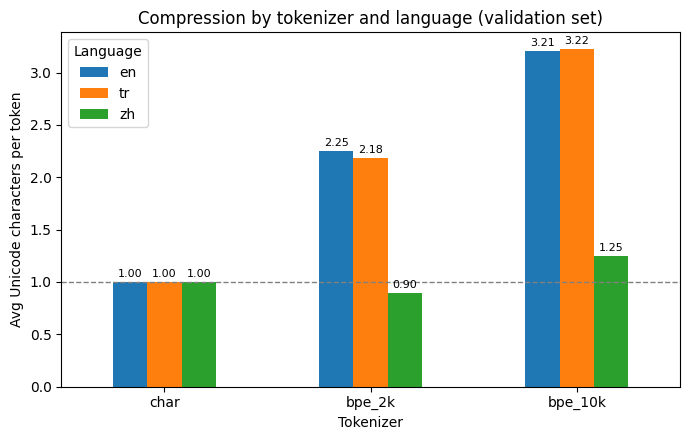

In [138]:
import matplotlib.pyplot as plt

# Same data as before: rows = tokenizers, columns = languages
order = ["char", "bpe_2k", "bpe_10k"]
pivot = results.pivot(index="tokenizer", columns="language", values="avg_chars_per_token").loc[order]

ax = pivot.plot(kind="bar", figsize=(7, 4.5))

# Write the value on top of every bar so the reader does not have to guess from the axis
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

# Dashed line at 1.0 = "one character per token". Bars below it mean a token is LESS than one character
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)

ax.set_ylabel("Avg Unicode characters per token")
ax.set_xlabel("Tokenizer")
ax.set_title("Compression by tokenizer and language (validation set)")
plt.xticks(rotation=0)
plt.legend(title="Language")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/chars_per_token1.png", dpi=150)   
plt.show()

**Character level:** It gives exactly 1.0 characters per token, so total tokens equal the number of characters. All three languages need about 368k tokens, which is what the character balanced data leads us to expect. The vocabulary is large (9,443) because Chinese needs thousands of different characters. The average tokens per sentence differ (81, 99, 39) only because sentence lengths differ.

**BPE-2k:** English and Turkish shrink to less than half the size (about 164k and 169k tokens, roughly 2.2 characters per token). Chinese is the surprise. It needs 410k tokens, which is more than the 368k characters. Its 0.898 characters per token means each Chinese character costs on average about 1.1 tokens.

**BPE-10k:** Everything shrinks again. English and Turkish reach about 3.2 characters per token, so they are now almost identical (114.7k vs 114.3k tokens). Chinese is still far behind at 1.25 characters per token.

**Why I think the results look like this?**

- **Chinese is expensive because of bytes.** I built byte-level BPE, and one Chinese character is 3 bytes. A character only becomes one token if BPE happened to merge its 3 bytes.
  - In the 2k vocabulary there are only about 1,750 merges shared among three languages.
  - Only the very frequent Chinese characters get their own token, and the rest stay in 2–3 pieces.
  - That is why BPE-2k is worse than the plain character tokenizer for Chinese (410k vs 368k).
  - At 10k, more characters get merged, but Chinese still has thousands of different characters and a flatter frequency distribution, so it stays behind.

- **English and Turkish compress well.**
  - Letters are 1 byte each (Turkish has a few 2-byte letters).
  - Both languages repeat the same letter sequences over and over.
  - The pairs are frequent, so BPE merges them early.

## 1.6 Some more example sets

In [139]:
test_words = {
    "en": ["the", "international", "unbelievably", "Wikipedia"],
    "tr": ["evlerimizden", "Türkiye'nin", "öğretmenlerimizin", "kitaplar"],
    "zh": ["我们", "中华人民共和国", "北京大学", "经济发展"],
}

for lang, words in test_words.items():
    for w in words:
        print(f"[{lang}] {w}")
        for name, tok in tokenizers.items():
            print(f"   {name:8s}", " | ".join(tok.to_tokens(w)))

[en] the
   char     t | h | e
   bpe_2k   t | he
   bpe_10k  the
[en] international
   char     i | n | t | e | r | n | a | t | i | o | n | a | l
   bpe_2k   in | ter | n | ation | al
   bpe_10k  in | ternational
[en] unbelievably
   char     u | n | b | e | l | i | e | v | a | b | l | y
   bpe_2k   un | b | el | i | ev | ab | ly
   bpe_10k  un | b | eli | ev | ably
[en] Wikipedia
   char     W | i | k | i | p | e | d | i | a
   bpe_2k   W | ik | ip | ed | ia
   bpe_10k  W | ik | ip | ed | ia
[tr] evlerimizden
   char     e | v | l | e | r | i | m | i | z | d | e | n
   bpe_2k   ev | ler | im | iz | den
   bpe_10k  ev | ler | im | iz | den
[tr] Türkiye'nin
   char     T | ü | r | k | i | y | e | ' | n | i | n
   bpe_2k   T | ürk | iye | ' | nin
   bpe_10k  Türkiye | ' | nin
[tr] öğretmenlerimizin
   char     ö | ğ | r | e | t | m | e | n | l | e | r | i | m | i | z | i | n
   bpe_2k   ö | ğ | r | et | men | ler | im | iz | in
   bpe_10k  ö | ğ | ret | men | ler | im | iz | in
[tr] kit

In [140]:
#how many Chinese tokens are broken byte fragments?
for name in ["bpe_2k", "bpe_10k"]:
    tok = tokenizers[name]
    # Which vocabulary entries are incomplete pieces of a character?
    frag_ids = {i for i in range(tok.vocab_size()) if "\ufffd" in tok.id_to_readable(i)}
    for lang in LANGS:
        flat = [i for x in tok.encode_batch(valid[lang]) for i in x]
        share = 100 * sum(1 for i in flat if i in frag_ids) / len(flat)
        print(f"{name:8s} {lang}: {share:.1f}% of tokens are partial-byte fragments")

bpe_2k   en: 0.4% of tokens are partial-byte fragments
bpe_2k   tr: 0.8% of tokens are partial-byte fragments
bpe_2k   zh: 35.4% of tokens are partial-byte fragments
bpe_10k  en: 0.3% of tokens are partial-byte fragments
bpe_10k  tr: 0.4% of tokens are partial-byte fragments
bpe_10k  zh: 7.6% of tokens are partial-byte fragments


In [141]:
#tokens per word for English and Turkish
for name, tok in tokenizers.items():
    for lang in ["en", "tr"]:
        n_words  = sum(len(s.split()) for s in valid[lang])
        n_chars  = sum(len(w) for s in valid[lang] for w in s.split())
        n_tokens = sum(len(x) for x in tok.encode_batch(valid[lang]))
        print(f"{name:8s} {lang}: {n_chars/n_words:.1f} chars/word, {n_tokens/n_words:.2f} tokens/word")

char     en: 4.9 chars/word, 5.78 tokens/word
char     tr: 6.6 chars/word, 7.57 tokens/word
bpe_2k   en: 4.9 chars/word, 2.57 tokens/word
bpe_2k   tr: 6.6 chars/word, 3.47 tokens/word
bpe_10k  en: 4.9 chars/word, 1.80 tokens/word
bpe_10k  tr: 6.6 chars/word, 2.35 tokens/word


In [142]:
#Chinese single-character vs multi-character tokens in the vocabulary
def is_cjk(ch):
    return "\u4e00" <= ch <= "\u9fff"

for name in ["bpe_2k", "bpe_10k"]:
    tok = tokenizers[name]
    texts = [tok.id_to_readable(i) for i in range(tok.vocab_size())]
    single = [t for t in texts if len(t) == 1 and is_cjk(t)]
    multi  = [t for t in texts if len(t) >= 2 and all(is_cjk(c) for c in t)]
    print(f"{name}: {len(single)} single Chinese characters, {len(multi)} multi-character Chinese tokens")
    # Lower ids = merged earlier = more frequent in training, so these are the "strongest" units
    print("   first multi-character tokens:", multi[:15])

bpe_2k: 662 single Chinese characters, 49 multi-character Chinese tokens
   first multi-character tokens: ['可以', '使用', '一个', '政府', '一個', '自己', '因此', '人口', '以及', '公司', '第一', '其中', '部分', '其他', '平方']
bpe_10k: 2391 single Chinese characters, 2056 multi-character Chinese tokens
   first multi-character tokens: ['可以', '使用', '一个', '政府', '一個', '自己', '因此', '人口', '以及', '公司', '第一', '其中', '部分', '其他', '平方']


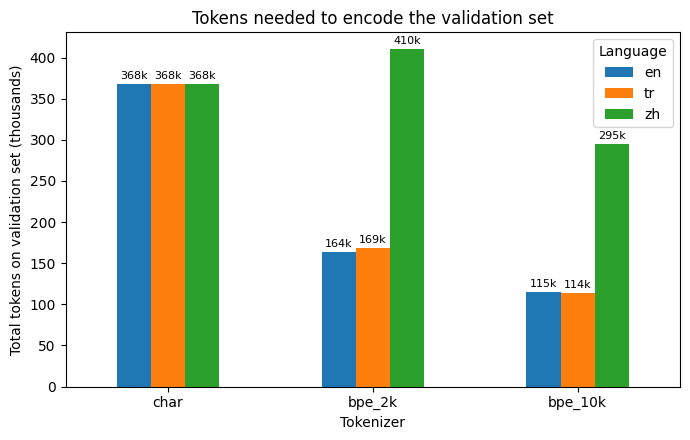

In [143]:
pivot_tokens = results.pivot(index="tokenizer", columns="language", values="total_tokens").loc[order]
ax = (pivot_tokens / 1000).plot(kind="bar", figsize=(7, 4.5))        # divide by 1000 -> thousands of tokens
for container in ax.containers:
    ax.bar_label(container, fmt="%.0fk", fontsize=8, padding=2)
ax.set_ylabel("Total tokens on validation set (thousands)")
ax.set_xlabel("Tokenizer")
ax.set_title("Tokens needed to encode the validation set")
plt.xticks(rotation=0)
plt.legend(title="Language")
plt.tight_layout()
plt.savefig("outputs_part1/total_tokens.png", dpi=150)
plt.show()

## Part 2

In [144]:
GPU_ID = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID

import json, math, time, random, contextlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

assert torch.cuda.is_available(), "No GPU found! Check GPU_ID / nvidia-smi."
DEVICE = "cuda"
print("Using GPU:", torch.cuda.get_device_name(0), "| torch", torch.__version__)

# Paths
PART1_DIR = "outputs_part1" # where Part 1 saved bpe_2k.json and bpe_10k.json
OUT_DIR   = "outputs_part2_prelim" # where we save checkpoints, logs, tables
os.makedirs(OUT_DIR, exist_ok=True)

# Model hyperparameters
BLOCK   = 256     # context length in tokens
D_MODEL = 256     # hidden size
N_HEAD  = 4       # attention heads (256 / 4 = 64 dims per head)
N_LAYER = 2       # Transformer layers
D_FF    = 1024    # feed-forward inner size
DROPOUT = 0.1     # regularisation


# Training hyperparameters 
BATCH        = 64
LR           = 1e-3
WARMUP_STEPS = 200
WEIGHT_DECAY = 0.01
EPOCHS       = 2
EVALS_PER_EPOCH = 2
SEED         = 2326
TIE_WEIGHTS  = False

# USE_BF16 = torch.cuda.is_bf16_supported(including_emulation=False)
# def amp():
#     # returns a fresh "mixed precision" context (or a do-nothing context)
#     if USE_BF16:
#         return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
#     return contextlib.nullcontext()

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Save the config so the run is reproducible and documented
config = dict(BLOCK=BLOCK, D_MODEL=D_MODEL, N_HEAD=N_HEAD, N_LAYER=N_LAYER, D_FF=D_FF, DROPOUT=DROPOUT,
              BATCH=BATCH, LR=LR, WARMUP_STEPS=WARMUP_STEPS, WEIGHT_DECAY=WEIGHT_DECAY,
              EPOCHS=EPOCHS, SEED=SEED, TIE_WEIGHTS=TIE_WEIGHTS)
with open(f"{OUT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)
print(config)

Using GPU: NVIDIA GeForce GTX 1080 Ti | torch 2.4.1+cu121
{'BLOCK': 256, 'D_MODEL': 256, 'N_HEAD': 4, 'N_LAYER': 2, 'D_FF': 1024, 'DROPOUT': 0.1, 'BATCH': 64, 'LR': 0.001, 'WARMUP_STEPS': 200, 'WEIGHT_DECAY': 0.01, 'EPOCHS': 2, 'SEED': 2326, 'TIE_WEIGHTS': False}


In [145]:
# The seed is fixed, so every tokenizer gets exactly the same text in exactly the same order.
train_sents = [s for lang in LANGS for s in train[lang]]
random.Random(SEED).shuffle(train_sents)
valid_all = [s for lang in LANGS for s in valid[lang]]      # all validation sentences together


In [146]:
def make_stream(tok, sentences):
    eos_id = tok.vocab_size()
    ids = []
    for sent_ids in tok.encode_batch(sentences):# encodes all sentences with this tokenizer
        ids.extend(sent_ids)# add the token ids of the sentence
        ids.append(eos_id)
    return torch.tensor(ids, dtype=torch.long, device=DEVICE)

In [147]:
data = {}
for name, tok in tokenizers.items():
    d = {}
    d["vocab"] = tok.vocab_size() + 1# +1 because of the EOS id
    d["train"] = make_stream(tok, train_sents)
    d["valid"] = make_stream(tok, valid_all)
    d["valid_chars"] = sum(len(s) + 1 for s in valid_all)# number of characters (+1 per EOS)
    d["valid_lang"] = {}# one validation stream per language
    for lang in LANGS:
        d["valid_lang"][lang] = (make_stream(tok, valid[lang]),
                                 sum(len(s) + 1 for s in valid[lang]))
    data[name] = d

In [148]:
#4.how much training each model will get
rows = []
for name, d in data.items():
    steps_per_epoch = len(d["train"]) // (BATCH * BLOCK)# steps needed to read the text once
    rows.append({"tokenizer": name,
                 "vocab (incl. EOS)": d["vocab"],
                 "train tokens": len(d["train"]),
                 "valid tokens": len(d["valid"]),
                 "steps per epoch": steps_per_epoch,
                 f"total steps ({EPOCHS} epochs)": steps_per_epoch * EPOCHS})
policy_table = pd.DataFrame(rows)
policy_table.to_csv(f"{OUT_DIR}/training_policy_table.csv", index=False)
policy_table

,tokenizer,vocab (incl. EOS),train tokens,valid tokens,steps per epoch,total steps (2 epochs)
0,char,9444,8980877,1122747,548,1096
1,bpe_2k,2001,6072092,760666,370,740
2,bpe_10k,10001,4305879,541486,262,524


## 2.1 Transformer layers

In [149]:
# One Transformer layer = attention + small feed-forward network.
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1  = nn.LayerNorm(D_MODEL) # normalising values before attention
        self.attn = nn.MultiheadAttention(D_MODEL, N_HEAD, dropout=DROPOUT, batch_first=True)
        self.ln2  = nn.LayerNorm(D_MODEL)  # normalising values before the feed-forward part
        # feed-forward network
        self.mlp  = nn.Sequential(
            nn.Linear(D_MODEL, D_FF),
            nn.GELU(),
            nn.Linear(D_FF, D_MODEL),
            nn.Dropout(DROPOUT),
        )
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x, mask):
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=mask, need_weights=False)  # every position looks at earlier ones
        x = x + self.drop(a) # add the input back
        x = x + self.mlp(self.ln2(x))  # feed-forward + residual connection
        return x

In [150]:
class TransformerLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, D_MODEL)
        self.pos_emb = nn.Embedding(BLOCK, D_MODEL)
        self.drop    = nn.Dropout(DROPOUT)
        self.blocks  = nn.ModuleList([Block() for _ in range(N_LAYER)])
        self.ln_f    = nn.LayerNorm(D_MODEL)
        self.head    = nn.Linear(D_MODEL, vocab_size, bias=False)
        #small random weights
        for w in [self.tok_emb.weight, self.pos_emb.weight, self.head.weight]:
            nn.init.normal_(w, mean=0.0, std=0.02)

    def forward(self, x):
        T = x.shape[1]
        positions = torch.arange(T, device=x.device)
        h = self.drop(self.tok_emb(x) + self.pos_emb(positions))
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=x.device), diagonal=1)
        for block in self.blocks:
            h = block(h, mask)
        h = self.ln_f(h)
        return self.head(h) 

In [151]:
rows = []
for name, d in data.items():
    model = TransformerLM(d["vocab"])# build a model (not trained)
    total  = sum(p.numel() for p in model.parameters())# every parameter
    emb_in = model.tok_emb.weight.numel()# input embeddings = V x D
    out    = model.head.weight.numel()# output layer = D x V
    pos    = model.pos_emb.weight.numel()# position embeddings
    rows.append({
        "tokenizer": name,
        "vocab (incl. EOS)": d["vocab"],
        "input embeddings": emb_in,
        "output layer": out,
        "position embeddings": pos,
        "transformer layers": total - emb_in - out - pos,
        "TOTAL": total,
        "start loss should be ~ln(V)": round(math.log(d["vocab"]), 2),
    })
    del model
param_table = pd.DataFrame(rows)
param_table.to_csv(f"{OUT_DIR}/parameter_counts.csv", index=False)
param_table

,tokenizer,vocab (incl. EOS),input embeddings,output layer,position embeddings,transformer layers,TOTAL,start loss should be ~ln(V)
0,char,9444,2417664,2417664,65536,1580032,6480896,9.15
1,bpe_2k,2001,512256,512256,65536,1580032,2670080,7.60
2,bpe_10k,10001,2560256,2560256,65536,1580032,6766080,9.21


In [152]:
# Pick random windows of BLOCK tokens from the stream.
# x = the tokens the model sees
#y = the same window shifted by one = the "next token" it should predict
def get_batch(stream):
    starts = torch.randint(0, len(stream) - BLOCK - 1, (BATCH,), device=DEVICE)   # random start positions
    offsets = torch.arange(BLOCK, device=DEVICE)
    idx = starts[:, None] + offsets[None, :]# (BATCH, BLOCK) positions
    return stream[idx], stream[idx + 1]

# Average loss (nats per token) over a whole stream, using non-overlapping windows.
@torch.no_grad()
def evaluate(model, stream, vocab):
    model.eval()
    n_windows = (len(stream) - 1) // BLOCK
    offsets = torch.arange(BLOCK, device=DEVICE)
    total_loss, total_tokens = 0.0, 0
    for first in range(0, n_windows, 64):
        w = torch.arange(first, min(first + 64, n_windows), device=DEVICE)
        idx = w[:, None] * BLOCK + offsets[None, :]
        x, y = stream[idx], stream[idx + 1]
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab), y.reshape(-1), reduction="sum")
        total_loss += loss.item()
        total_tokens += y.numel()
    model.train()# switch dropout back on
    return total_loss / total_tokens

# Convert loss per token into bits per character, so tokenizers can be compared fairly:
# bits per token = loss / ln(2)
#tokens per character = len(stream) / n_chars
def bits_per_char(loss_per_token, stream, n_chars):
    return loss_per_token / math.log(2) * (len(stream) / n_chars)

# Learning rate: rises slowly for the first steps (warm-up), then falls smoothly to 10% of its peak.
def get_lr(step, total_steps):
    if step < WARMUP_STEPS:
        return LR * step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (total_steps - WARMUP_STEPS)
    return LR * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress)))

In [153]:
def train_model(name):
    d = data[name]
    vocab = d["vocab"]

    torch.manual_seed(SEED)
    model = TransformerLM(vocab).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    steps_per_epoch = len(d["train"]) // (BATCH * BLOCK)
    total_steps = steps_per_epoch * EPOCHS
    eval_every = steps_per_epoch // EVALS_PER_EPOCH
    print(f"=== {name}: vocab {vocab} | {steps_per_epoch} steps/epoch | {total_steps} steps total ===")

    history = []
    best_val = float("inf")
    running_loss, running_n = 0.0, 0
    start_time = time.time()

    for step in range(1, total_steps + 1):
        lr = get_lr(step, total_steps)
        for group in optimizer.param_groups:
            group["lr"] = lr

        # predict the next token everywhere in a random batch
        x, y = get_batch(d["train"])
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab), y.view(-1))

        # compute gradients and update the weights
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # stops rare huge updates
        optimizer.step()

        running_loss += loss.item()
        running_n += 1

        # measuring validation loss and save the best model so far
        if step % eval_every == 0 or step == total_steps:
            val_loss = evaluate(model, d["valid"], vocab)
            val_bpc = bits_per_char(val_loss, d["valid"], d["valid_chars"])
            train_loss = running_loss / running_n
            history.append({"tokenizer": name, "step": step, "epoch": step / steps_per_epoch,
                            "train_loss": train_loss, "val_loss": val_loss, "val_bpc": val_bpc,
                            "seconds": time.time() - start_time})
            print(f"step {step:5d} | epoch {step/steps_per_epoch:5.2f} | train loss {train_loss:.3f} | "
                  f"val loss {val_loss:.3f} | val BPC {val_bpc:.3f} | {time.time()-start_time:5.0f}s")
            running_loss, running_n = 0.0, 0

            if val_loss < best_val:
                best_val = val_loss
                torch.save(model.state_dict(), f"{OUT_DIR}/{name}_best.pt")

    pd.DataFrame(history).to_csv(f"{OUT_DIR}/{name}_history.csv", index=False)
    return history

In [154]:
train_model("char")

=== char: vocab 9444 | 548 steps/epoch | 1096 steps total ===
step   274 | epoch  0.50 | train loss 4.795 | val loss 3.631 | val BPC 5.238 |    27s
step   548 | epoch  1.00 | train loss 3.374 | val loss 3.109 | val BPC 4.486 |    55s
step   822 | epoch  1.50 | train loss 3.074 | val loss 2.924 | val BPC 4.219 |    83s
step  1096 | epoch  2.00 | train loss 2.972 | val loss 2.864 | val BPC 4.131 |   110s


[{'tokenizer': 'char',
  'step': 274,
  'epoch': 0.5,
  'train_loss': 4.795358212324825,
  'val_loss': 3.630543711193611,
  'val_bpc': 5.237767407869636,
  'seconds': 27.322725772857666},
 {'tokenizer': 'char',
  'step': 548,
  'epoch': 1.0,
  'train_loss': 3.373515422326805,
  'val_loss': 3.1094569729290638,
  'val_bpc': 4.485998154702368,
  'seconds': 54.8418173789978},
 {'tokenizer': 'char',
  'step': 822,
  'epoch': 1.5,
  'train_loss': 3.074117464740781,
  'val_loss': 2.924279964364377,
  'val_bpc': 4.218844202759442,
  'seconds': 82.51321530342102},
 {'tokenizer': 'char',
  'step': 1096,
  'epoch': 2.0,
  'train_loss': 2.97205289523967,
  'val_loss': 2.863595367048866,
  'val_bpc': 4.13129483515401,
  'seconds': 110.31885504722595}]

In [155]:
train_model("bpe_2k")

=== bpe_2k: vocab 2001 | 370 steps/epoch | 740 steps total ===
step   185 | epoch  0.50 | train loss 6.453 | val loss 5.465 | val BPC 5.342 |    13s
step   370 | epoch  1.00 | train loss 5.130 | val loss 4.766 | val BPC 4.659 |    26s
step   555 | epoch  1.50 | train loss 4.664 | val loss 4.466 | val BPC 4.365 |    39s
step   740 | epoch  2.00 | train loss 4.494 | val loss 4.367 | val BPC 4.269 |    52s


[{'tokenizer': 'bpe_2k',
  'step': 185,
  'epoch': 0.5,
  'train_loss': 6.452831840515136,
  'val_loss': 5.464916957263311,
  'val_bpc': 5.341585783519785,
  'seconds': 12.81084394454956},
 {'tokenizer': 'bpe_2k',
  'step': 370,
  'epoch': 1.0,
  'train_loss': 5.129803714236697,
  'val_loss': 4.766148672806859,
  'val_bpc': 4.658587164617395,
  'seconds': 25.80629539489746},
 {'tokenizer': 'bpe_2k',
  'step': 555,
  'epoch': 1.5,
  'train_loss': 4.6640802125673035,
  'val_loss': 4.466071468778268,
  'val_bpc': 4.365282044057947,
  'seconds': 38.828991651535034},
 {'tokenizer': 'bpe_2k',
  'step': 740,
  'epoch': 2.0,
  'train_loss': 4.494469487989271,
  'val_loss': 4.367061105251151,
  'val_bpc': 4.268506126990322,
  'seconds': 51.883394956588745}]

In [156]:
train_model("bpe_10k")

=== bpe_10k: vocab 10001 | 262 steps/epoch | 524 steps total ===
step   131 | epoch  0.50 | train loss 8.204 | val loss 7.319 | val BPC 5.093 |    14s
step   262 | epoch  1.00 | train loss 6.806 | val loss 6.456 | val BPC 4.492 |    29s
step   393 | epoch  1.50 | train loss 6.324 | val loss 6.175 | val BPC 4.297 |    44s
step   524 | epoch  2.00 | train loss 6.124 | val loss 6.058 | val BPC 4.215 |    58s


[{'tokenizer': 'bpe_10k',
  'step': 131,
  'epoch': 0.5,
  'train_loss': 8.203845155148105,
  'val_loss': 7.319016817782788,
  'val_bpc': 5.09251847536271,
  'seconds': 14.421710968017578},
 {'tokenizer': 'bpe_10k',
  'step': 262,
  'epoch': 1.0,
  'train_loss': 6.805618275212877,
  'val_loss': 6.456164249573475,
  'val_bpc': 4.492151956946754,
  'seconds': 29.022704362869263},
 {'tokenizer': 'bpe_10k',
  'step': 393,
  'epoch': 1.5,
  'train_loss': 6.32414498583961,
  'val_loss': 6.174986804574376,
  'val_bpc': 4.296510743220595,
  'seconds': 43.55968403816223},
 {'tokenizer': 'bpe_10k',
  'step': 524,
  'epoch': 2.0,
  'train_loss': 6.124175100836135,
  'val_loss': 6.058054380664871,
  'val_bpc': 4.215150016233156,
  'seconds': 58.13406181335449}]

## 2.2 Learning Curve

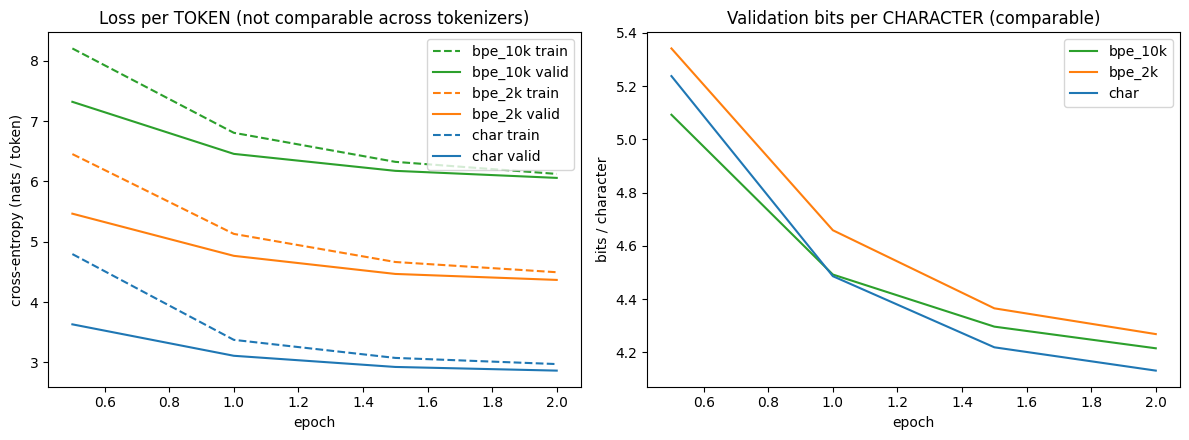

In [157]:
import matplotlib.pyplot as plt

colors = {"char": "tab:blue", "bpe_2k": "tab:orange", "bpe_10k": "tab:green"}
history = pd.concat([pd.read_csv(f"{OUT_DIR}/{n}_history.csv") for n in ["char", "bpe_2k", "bpe_10k"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, g in history.groupby("tokenizer"):
    axes[0].plot(g["epoch"], g["train_loss"], "--", color=colors[name], label=f"{name} train")# dashed = training
    axes[0].plot(g["epoch"], g["val_loss"],   "-",  color=colors[name], label=f"{name} valid")# solid = validation
    axes[1].plot(g["epoch"], g["val_bpc"], "-", color=colors[name], label=name)

axes[0].set_title("Loss per TOKEN (not comparable across tokenizers)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy (nats / token)")
axes[1].set_title("Validation bits per CHARACTER (comparable)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("bits / character")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/learning_curves.png", dpi=150)
plt.show()

OUT_DIR is: outputs_part2_prelim
Files there: ['config.json', 'training_policy_table.csv', 'parameter_counts.csv', 'char_best.pt', 'char_history.csv', 'bpe_2k_best.pt', 'bpe_2k_history.csv', 'bpe_10k_best.pt', 'bpe_10k_history.csv', 'learning_curves.png']
